In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('..').resolve()
if not (PROJECT_ROOT / 'src' / 'utils.py').exists():
    for candidate in [Path.cwd() / 'ing_del_dato', Path.cwd().parent / 'ing_del_dato']:
        if (candidate / 'src' / 'utils.py').exists():
            PROJECT_ROOT = candidate.resolve()
            break

sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import crear_directorios, limpiar_texto, normalizar_metricas, resumen_nulos, detectar_outliers_iqr

DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
OUTPUTS_FIG = PROJECT_ROOT / 'outputs' / 'figures'
OUTPUTS_TABLES = PROJECT_ROOT / 'outputs' / 'tables'

crear_directorios([DATA_RAW, DATA_PROCESSED, OUTPUTS_FIG, OUTPUTS_TABLES])

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True


## 1. Carga de datos

Cargamos los datos originales desde `data/raw/` y comprobamos que existen antes de continuar.


In [2]:
tweets_path = DATA_RAW / 'tweets_gobierno_economia.csv'
icc_path = DATA_RAW / 'evolucion_de_la_confianza_del_consumidor_desde_2004.csv'

if not tweets_path.exists():
    raise FileNotFoundError(f'No se encontró el archivo: {tweets_path}')
if not icc_path.exists():
    raise FileNotFoundError(f'No se encontró el archivo: {icc_path}')

tweets_raw = pd.read_csv(tweets_path)
icc_raw = pd.read_csv(icc_path, sep=';')

print('Tweets cargados:', tweets_raw.shape)
print('ICC cargado:', icc_raw.shape)


Tweets cargados: (11198, 11)
ICC cargado: (267, 3)


## 2. Exploración inicial

Revisamos estructura, valores nulos y duplicados en los datos originales.


In [3]:
print('--- Tweets: vistas iniciales ---')
display(tweets_raw.head(3))
print(tweets_raw.dtypes.to_frame(name='tipo'))
print('Nulos por columna en tweets:')
display(resumen_nulos(tweets_raw))
print('Duplicados por id en tweets:', tweets_raw.duplicated(subset=['id']).sum())
print('--- ICC: vistas iniciales ---')
display(icc_raw.head(3))
print(icc_raw.dtypes.to_frame(name='tipo'))
print('Nulos por columna en ICC:')
display(resumen_nulos(icc_raw))


--- Tweets: vistas iniciales ---


,id,fecha,username,contenido,hashtags,tipo,url_media,comentarios,retweets,likes,views
0,2047346501915963634,"Apr 23, 2026 · 4:06 PM UTC",@_minecogob,El sexto desembolso del Plan de Recuperación asciende a unos 7.000M€ (5.600 en préstamos y 2.000...,NaN,Texto simple,NaN,0,30,53,"1,163"
1,2047344028933320813,"Apr 23, 2026 · 3:57 PM UTC",@_minecogob,Gracias a 10.500M€ en préstamos del Plan de Recuperación movilizaremos unos 120.000 millones en ...,NaN,Texto simple,NaN,11,63,123,"2,778"
2,2047314800384823490,"Apr 23, 2026 · 2:01 PM UTC",@_minecogob,El VP1 @carlos_cuerpo comparece en el @Congreso_Es para dar cuenta de los avances en la ejecució...,NaN,Imagen,https://nitter.net/pic/orig/media%2FHGlw8NnWkAA03cg.jpg,2,18,34,727


              tipo
id           int64
fecha          str
username       str
contenido      str
hashtags       str
tipo           str
url_media      str
comentarios    str
retweets       str
likes          str
views          str
Nulos por columna en tweets:


,nulos,%_nulos
url_media,5387,48.11
hashtags,2646,23.63
contenido,8,0.07
username,0,0.00
fecha,0,0.00
id,0,0.00
tipo,0,0.00
comentarios,0,0.00
retweets,0,0.00
likes,0,0.00


Duplicados por id en tweets: 65
--- ICC: vistas iniciales ---


,Año,Periodo,Confianza del consumidor
0,2004,Septiembre,"96,69"
1,2004,Octubre,"90,64"
2,2004,Noviembre,"90,05"


                         tipo
Año                       str
Periodo                   str
Confianza del consumidor  str
Nulos por columna en ICC:


,nulos,%_nulos
Periodo,14,5.24
Confianza del consumidor,14,5.24
Año,4,1.50


## 3. Validación de estructura

Comprobamos que las columnas clave existen en cada dataset antes de normalizar.


In [4]:
cols_requeridas_tweets = ['id', 'fecha', 'username', 'contenido', 'comentarios', 'retweets', 'likes', 'views']
cols_faltantes_tweets = [c for c in cols_requeridas_tweets if c not in tweets_raw.columns]
cols_requeridas_icc = ['Año', 'Periodo', 'Confianza del consumidor']
cols_faltantes_icc = [c for c in cols_requeridas_icc if c not in icc_raw.columns]

if cols_faltantes_tweets:
    raise ValueError(f'Faltan columnas en tweets: {cols_faltantes_tweets}')
if cols_faltantes_icc:
    raise ValueError(f'Faltan columnas en ICC: {cols_faltantes_icc}')

print('Columnas requeridas de tweets presentes.')
print('Columnas requeridas de ICC presentes.')


Columnas requeridas de tweets presentes.
Columnas requeridas de ICC presentes.


## 4. Conversión y normalización de fechas

Normalizamos la fecha de los tweets y convertimos los periodos de ICC a la primera fecha de cada mes.


In [5]:
tweets = tweets_raw.copy()
tweets['fecha_limpia'] = (
    tweets['fecha']
    .astype(str)
    .str.replace(' · ', ' ', regex=False)
    .str.replace(' UTC', '', regex=False)
)
tweets['fecha_dt'] = pd.to_datetime(
    tweets['fecha_limpia'],
    format='%b %d, %Y %I:%M %p',
    errors='coerce'
)
n_nulos_fecha = tweets['fecha_dt'].isna().sum()
print('Fechas no parseadas en tweets:', n_nulos_fecha)
if n_nulos_fecha > 0:
    display(tweets[tweets['fecha_dt'].isna()][['fecha', 'fecha_limpia']].head(10))

tweets['mes'] = tweets['fecha_dt'].dt.to_period('M').dt.to_timestamp()

icc = icc_raw.copy()
icc = icc[pd.to_numeric(icc['Año'], errors='coerce').notna()].copy()
icc['Año'] = icc['Año'].astype(int)
meses_es = {
    'Enero': 1, 'Febrero': 2, 'Marzo': 3, 'Abril': 4,
    'Mayo': 5, 'Junio': 6, 'Julio': 7, 'Agosto': 8,
    'Septiembre': 9, 'Octubre': 10, 'Noviembre': 11, 'Diciembre': 12
}
icc['mes_num'] = icc['Periodo'].map(meses_es)
filas_mes_nulo = icc[icc['mes_num'].isna()]
print('Filas con mes_num nulo en ICC:', len(filas_mes_nulo))
if not filas_mes_nulo.empty:
    display(filas_mes_nulo[['Año', 'Periodo']].head(10))

icc['fecha_mes'] = pd.to_datetime(
    dict(year=icc['Año'], month=icc['mes_num'], day=1),
    errors='coerce'
)
icc['ICC'] = (
    icc['Confianza del consumidor']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float)
)
icc = icc[['fecha_mes', 'ICC']].sort_values('fecha_mes').reset_index(drop=True)
print('ICC normalizado. Rango de fechas:', icc['fecha_mes'].min(), 'a', icc['fecha_mes'].max())


Fechas no parseadas en tweets: 0
Filas con mes_num nulo en ICC: 0
ICC normalizado. Rango de fechas: 2004-09-01 00:00:00 a 2026-01-01 00:00:00


## 5. Filtrado temporal 2020–2025

Usamos `FECHA_FIN = pd.Timestamp('2026-01-01')` con un filtro exclusivo para incluir todos los datos hasta el 31 de diciembre de 2025 sin sesgo de límite.


In [6]:
FECHA_INICIO = pd.Timestamp('2020-01-01')
FECHA_FIN = pd.Timestamp('2026-01-01')

mask_tweets = (tweets['fecha_dt'] >= FECHA_INICIO) & (tweets['fecha_dt'] < FECHA_FIN)
tweets_periodo = tweets[mask_tweets].copy().reset_index(drop=True)

mask_icc = (icc['fecha_mes'] >= FECHA_INICIO) & (icc['fecha_mes'] < FECHA_FIN)
icc_periodo = icc[mask_icc].copy().reset_index(drop=True)

print('Tweets en periodo 2020-2025:', tweets_periodo.shape[0])
print('ICC en periodo 2020-2025:', icc_periodo.shape[0])


Tweets en periodo 2020-2025: 7319
ICC en periodo 2020-2025: 68


## 6. Corpus principal: @_minecogob

@_minecogob es el corpus principal porque es la cuenta institucional relevante del Ministerio de Comercio que ofrece cobertura mensual consistente en el periodo de estudio.


Tweets @_minecogob en 2020-2025: 4606


,n_tweets
fecha_dt,
2020,699
2021,1079
2022,1213
2023,858
2024,444
2025,313


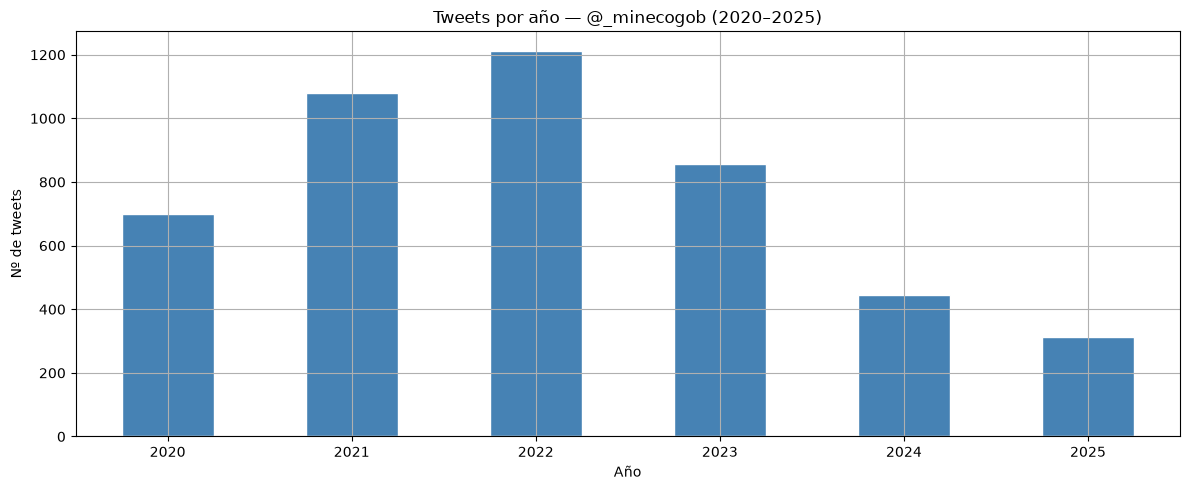

In [7]:
CUENTA_PRINCIPAL = '@_minecogob'
tweets_minecogob = tweets_periodo[tweets_periodo['username'] == CUENTA_PRINCIPAL].copy().reset_index(drop=True)
print('Tweets @_minecogob en 2020-2025:', tweets_minecogob.shape[0])

anual_minecogob = tweets_minecogob.groupby(tweets_minecogob['fecha_dt'].dt.year).size()
display(anual_minecogob.rename('n_tweets').to_frame())

fig, ax = plt.subplots()
anual_minecogob.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Tweets por año — @_minecogob (2020–2025)')
ax.set_xlabel('Año')
ax.set_ylabel('Nº de tweets')
plt.xticks(rotation=0)
plt.tight_layout()
fig.savefig(OUTPUTS_FIG / 'tweets_por_anio_minecogob.png', dpi=150)
plt.show()


## 7. Corpus complementario: @SE_Comercio

@SE_Comercio se utiliza como corpus descriptivo complementario porque aporta contexto adicional desde otra cuenta económica relevante del sector público, pero no es el foco principal del análisis.


In [8]:
CUENTA_COMPLEMENTARIA = '@SE_Comercio'
if CUENTA_COMPLEMENTARIA in tweets_periodo['username'].unique():
    tweets_comercio = tweets_periodo[tweets_periodo['username'] == CUENTA_COMPLEMENTARIA].copy().reset_index(drop=True)
    print('Tweets @SE_Comercio en 2020-2025:', tweets_comercio.shape[0])
    display(tweets_comercio.groupby(tweets_comercio['fecha_dt'].dt.year).size().rename('n_tweets').to_frame())
else:
    tweets_comercio = pd.DataFrame(columns=tweets_periodo.columns)
    print('@SE_Comercio no encontrada en el dataset.')

if not tweets_comercio.empty:
    # Eliminación de duplicados en el corpus complementario
    tweets_comercio = (
        tweets_comercio
        .drop_duplicates(subset=["id"], keep="first")
        .reset_index(drop=True)
    )

    # Aplicar la misma limpieza básica que al corpus principal
    tweets_comercio["texto_limpio"] = tweets_comercio["contenido"].apply(limpiar_texto)
    tweets_comercio = normalizar_metricas(tweets_comercio, ["comentarios", "retweets", "likes", "views"])
    tweets_comercio["mes"] = tweets_comercio["fecha_dt"].dt.to_period("M").dt.to_timestamp()


Tweets @SE_Comercio en 2020-2025: 38


,n_tweets
fecha_dt,
2023,7
2024,20
2025,11


## 8. Tratamiento de nulos y duplicados en @_minecogob

Verificamos calidad de datos y eliminamos duplicados por `id` para el corpus principal.


In [9]:
resumen_nulos_tweets = resumen_nulos(tweets_minecogob)
print('Resumen de nulos tweets @_minecogob:')
display(resumen_nulos_tweets)

tweets_minecogob['texto_limpio'] = tweets_minecogob['contenido'].apply(limpiar_texto)
n_vacios = (tweets_minecogob['texto_limpio'].str.strip() == '').sum()
print('Tweets con texto vacío tras limpieza:', n_vacios)

n_dup_id = tweets_minecogob.duplicated(subset=['id']).sum()
n_dup_contenido = tweets_minecogob.duplicated(subset=['contenido', 'fecha_dt']).sum()
print('Duplicados por id:', n_dup_id)
print('Duplicados por contenido+fecha:', n_dup_contenido)

resumen_calidad_tweets = pd.DataFrame([
    {'item': 'registros_iniciales', 'valor': len(tweets_minecogob)},
    {'item': 'nulos_total', 'valor': int(resumen_nulos_tweets['nulos'].sum())},
    {'item': 'texto_vacio', 'valor': int(n_vacios)},
    {'item': 'duplicados_id', 'valor': int(n_dup_id)},
    {'item': 'duplicados_contenido_fecha', 'valor': int(n_dup_contenido)}
])

resumen_calidad_tweets.to_csv(OUTPUTS_TABLES / 'resumen_calidad_tweets.csv', index=False)
print('Guardado: resumen_calidad_tweets.csv')
resumen_nulos_tweets.to_csv(OUTPUTS_TABLES / 'resumen_nulos_tweets.csv', index=False)


Resumen de nulos tweets @_minecogob:


,nulos,%_nulos
url_media,2424,52.63
hashtags,1036,22.49
contenido,2,0.04
fecha,0,0.00
username,0,0.00
id,0,0.00
tipo,0,0.00
comentarios,0,0.00
retweets,0,0.00
likes,0,0.00


Tweets con texto vacío tras limpieza: 0
Duplicados por id: 14
Duplicados por contenido+fecha: 14
Guardado: resumen_calidad_tweets.csv


In [10]:
# Eliminación de duplicados por id
registros_antes_deduplicar = len(tweets_minecogob)

tweets_minecogob = (
    tweets_minecogob
    .drop_duplicates(subset=["id"], keep="first")
    .reset_index(drop=True)
)

registros_despues_deduplicar = len(tweets_minecogob)

print("Registros antes de deduplicar:", registros_antes_deduplicar)
print("Registros después de deduplicar:", registros_despues_deduplicar)
print("Duplicados eliminados:", registros_antes_deduplicar - registros_despues_deduplicar)

Registros antes de deduplicar: 4606
Registros después de deduplicar: 4592
Duplicados eliminados: 14


## 9. Normalización de métricas numéricas

Convertimos las métricas de interacción en valores enteros para facilitar agregación y comparación.


In [11]:
metricas = ['comentarios', 'retweets', 'likes', 'views']
tweets_minecogob = normalizar_metricas(tweets_minecogob, metricas)
print('Estadísticas métricas de interacción:')
display(tweets_minecogob[metricas].describe().round(2))


Estadísticas métricas de interacción:


,comentarios,retweets,likes,views
count,4592.00,4592.00,4592.00,4592.00
mean,3.32,16.64,31.48,1774.50
std,10.73,32.66,78.61,19048.33
min,0.00,0.00,0.00,0.00
25%,0.00,4.00,6.00,0.00
50%,1.00,8.00,14.00,0.00
75%,2.00,18.00,34.00,787.25
max,267.00,1169.00,3650.00,809645.00


## 10. Detección de outliers

Los outliers se documentan porque pueden corresponder a publicaciones de alta repercusión; no se eliminan automáticamente para preservar el carácter de la serie.


,q1,q3,iqr,limite_inferior,limite_superior,n_outliers,%_outliers,total
columna,,,,,,,,
comentarios,0.0,2.00,2.00,-3.000,5.000,582,12.67,4592
retweets,4.0,18.00,14.00,-17.000,39.000,434,9.45,4592
likes,6.0,34.00,28.00,-36.000,76.000,399,8.69,4592
views,0.0,787.25,787.25,-1180.875,1968.125,569,12.39,4592


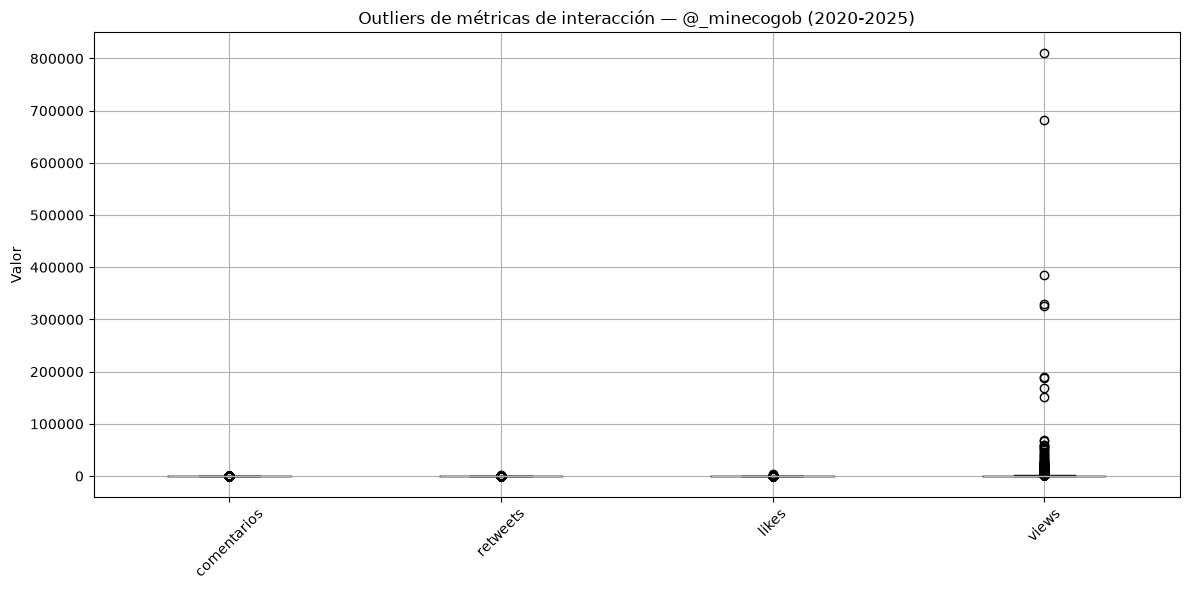

In [12]:
resumen_outliers = detectar_outliers_iqr(tweets_minecogob, metricas)
display(resumen_outliers)
resumen_outliers.to_csv(OUTPUTS_TABLES / 'resumen_outliers_interaccion.csv')

fig, ax = plt.subplots(figsize=(12, 6))
tweets_minecogob[metricas].boxplot(ax=ax)
ax.set_title('Outliers de métricas de interacción — @_minecogob (2020-2025)')
ax.set_ylabel('Valor')
plt.xticks(rotation=45)
plt.tight_layout()
fig.savefig(OUTPUTS_FIG / 'outliers_metricas_interaccion.png', dpi=150)
plt.show()


## 11. Cobertura mensual del corpus principal

La agregación se realiza a nivel mensual para sincronizar la frecuencia de los tweets con la serie mensual del ICC.


Meses con tweets: 72 / 72
Meses sin tweets: 0


,mes,n_tweets


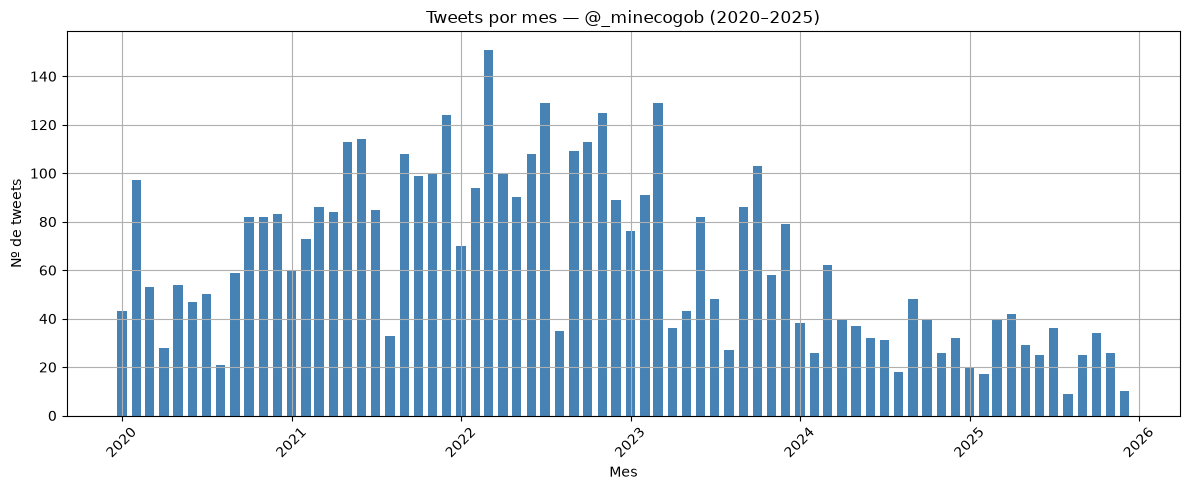

In [13]:
todos_los_meses = pd.date_range(FECHA_INICIO, FECHA_FIN - pd.Timedelta(days=1), freq='MS')
tweets_por_mes = (
    tweets_minecogob.groupby('mes').size()
    .reindex(todos_los_meses, fill_value=0)
    .rename('n_tweets')
    .reset_index()
    .rename(columns={'index': 'mes'})
)

print('Meses con tweets:', (tweets_por_mes['n_tweets'] > 0).sum(), '/ 72')
print('Meses sin tweets:', (tweets_por_mes['n_tweets'] == 0).sum())
display(tweets_por_mes[tweets_por_mes['n_tweets'] == 0].head(10))
tweets_por_mes.to_csv(OUTPUTS_TABLES / 'cobertura_mensual.csv', index=False)

fig, ax = plt.subplots()
ax.bar(tweets_por_mes['mes'], tweets_por_mes['n_tweets'], width=20, color='steelblue')
ax.set_title('Tweets por mes — @_minecogob (2020–2025)')
ax.set_xlabel('Mes')
ax.set_ylabel('Nº de tweets')
plt.xticks(rotation=45)
plt.tight_layout()
fig.savefig(OUTPUTS_FIG / 'tweets_por_mes_minecogob.png', dpi=150)
plt.show()


## 12. Preparación del ICC 2020–2025

Los meses sin ICC se documentan para preservar la evidencia de faltantes; no se imputan porque la ingeniería del dato se enfoca en validación y limpieza, no en creación de valores.


Meses con ICC disponible: 68 / 72
Meses sin ICC: 4


,mes
31,2022-08-01
43,2023-08-01
55,2024-08-01
67,2025-08-01


Meses sin ICC en 2020-2025:
2022-08, 2023-08, 2024-08, 2025-08


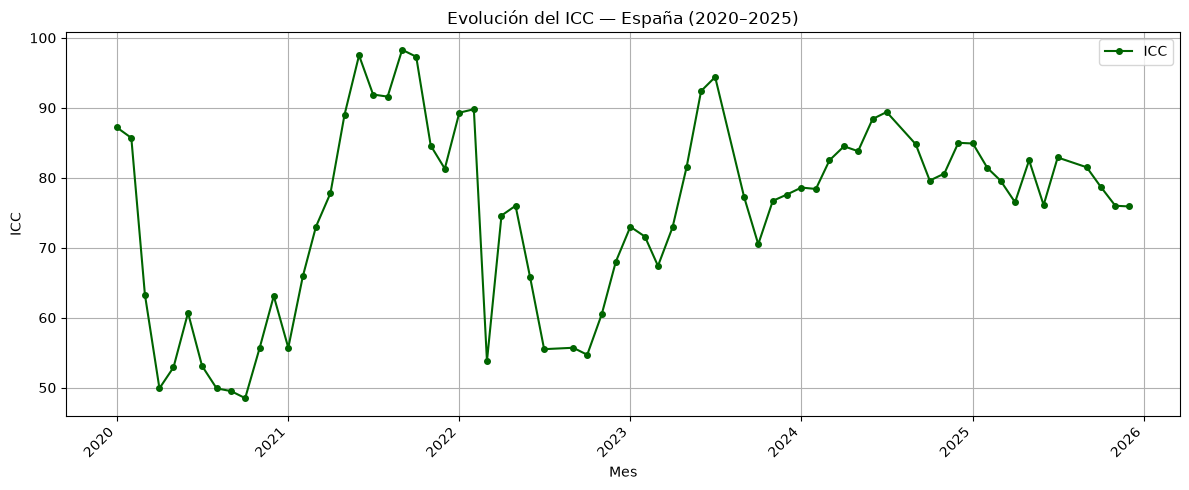

In [14]:
icc_completo = (
    icc_periodo.set_index('fecha_mes')
    .reindex(todos_los_meses)
    .rename_axis('mes')
    .reset_index()
)

print('Meses con ICC disponible:', icc_completo['ICC'].notna().sum(), '/ 72')
print('Meses sin ICC:', icc_completo['ICC'].isna().sum())
meses_sin_icc = icc_completo[icc_completo['ICC'].isna()]['mes']
display(meses_sin_icc.to_frame(name='mes'))
print('Meses sin ICC en 2020-2025:')
print(', '.join(meses_sin_icc.dt.strftime('%Y-%m')) if not meses_sin_icc.empty else 'Ninguno')

fig, ax = plt.subplots()
icc_completo.dropna(subset=['ICC']).plot(x='mes', y='ICC', ax=ax, marker='o', linewidth=1.5, markersize=4, color='darkgreen')
ax.set_title('Evolución del ICC — España (2020–2025)')
ax.set_xlabel('Mes')
ax.set_ylabel('ICC')
plt.xticks(rotation=45)
plt.tight_layout()
fig.savefig(OUTPUTS_FIG / 'icc_evolucion_2020_2025.png', dpi=150)
plt.show()


## 13. Agregación mensual de tweets @_minecogob

Agregamos los datos a nivel mensual para alinear la frecuencia de los tweets con la serie del ICC.


In [15]:
tweets_mensual = (
    tweets_minecogob.groupby('mes')
    .agg(
        n_tweets=('id', 'count'),
        comentarios_sum=('comentarios', 'sum'),
        retweets_sum=('retweets', 'sum'),
        likes_sum=('likes', 'sum'),
        views_sum=('views', 'sum'),
        texto_agregado=('texto_limpio', lambda x: ' '.join(x.dropna()))
    )
    .reset_index()
)
tweets_mensual = (
    tweets_mensual.set_index('mes')
    .reindex(todos_los_meses, fill_value=0)
    .rename_axis('mes')
    .reset_index()
)
tweets_mensual['texto_agregado'] = tweets_mensual['texto_agregado'].replace(0, '')
print('Dataset mensual de tweets creado:', tweets_mensual.shape)
display(tweets_mensual.head(6))


Dataset mensual de tweets creado: (72, 7)


,mes,n_tweets,comentarios_sum,retweets_sum,likes_sum,views_sum,texto_agregado
0,2020-01-01,43,61,829,1706,0,"el negociador jefe de la ue, , se ha reunido con la vp ante la salida formal de reino unido de l..."
1,2020-02-01,97,136,1518,3093,0,el e han firmado un acuerdo de colaboración para potenciar la competitividad de la industria esp...
2,2020-03-01,53,168,869,1205,0,la vicepresidenta estará esta noche en el informativo de para explicar las medidas económicas ap...
3,2020-04-01,28,148,699,956,0,"""no hay sostenibilidad económica o financiera si no viene acompañada de sostenibilidad social y ..."
4,2020-05-01,54,286,775,1582,0,la vicepresidenta en la comisióndereconstrucción del : no tenemos que dudar de nuestra capacidad...
5,2020-06-01,47,142,994,1746,0,el gobierno autoriza ayudas por 150 m€ para la extensión de bandaancha de muy alta velocidad. el...


## 14. Unión de tweets mensual + ICC

Construimos el dataset mensual integrado y conservamos flags de disponibilidad para cada fuente.


Meses con ambos disponibles: 68
Meses con solo ICC: 0
Meses con solo tweets: 4
Meses sin ninguno: 0


,mes,n_tweets,comentarios_sum,retweets_sum,likes_sum,views_sum,texto_agregado,ICC,icc_disponible,tweets_disponibles
0,2020-01-01,43,61,829,1706,0,"el negociador jefe de la ue, , se ha reunido con la vp ante la salida formal de reino unido de l...",87.2,True,True
1,2020-02-01,97,136,1518,3093,0,el e han firmado un acuerdo de colaboración para potenciar la competitividad de la industria esp...,85.7,True,True
2,2020-03-01,53,168,869,1205,0,la vicepresidenta estará esta noche en el informativo de para explicar las medidas económicas ap...,63.3,True,True
3,2020-04-01,28,148,699,956,0,"""no hay sostenibilidad económica o financiera si no viene acompañada de sostenibilidad social y ...",49.9,True,True
4,2020-05-01,54,286,775,1582,0,la vicepresidenta en la comisióndereconstrucción del : no tenemos que dudar de nuestra capacidad...,52.9,True,True
5,2020-06-01,47,142,994,1746,0,el gobierno autoriza ayudas por 150 m€ para la extensión de bandaancha de muy alta velocidad. el...,60.7,True,True
6,2020-07-01,50,122,861,1770,0,adjudicada la segunda convocatoria de ayudas para proyectos piloto 5g ➡ inversión de 40 m€ ➡ pro...,53.1,True,True
7,2020-08-01,21,83,567,777,0,"la vp señala que, desde mayo, la recuperación se va trasladando poco a poco al empleo: ✔️ más de...",49.9,True,True
8,2020-09-01,59,122,643,1240,0,la vp en : es momento de actuar: ➡con rigor en el diagnóstico ➡con diálogo y consenso social: ✔t...,49.5,True,True
9,2020-10-01,82,173,985,1695,0,🆕renovamos nuestra web 💻mineco.gob.es ✅diseño actualizado ✅navegación más ágil y operativa ✅más ...,48.5,True,True


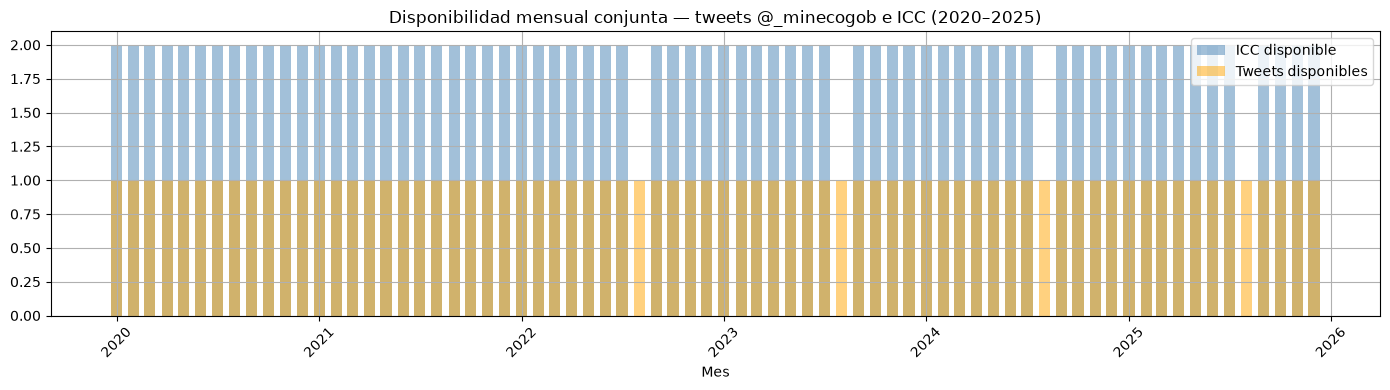

In [16]:
dataset_mensual = pd.merge(
    tweets_mensual,
    icc_completo,
    on='mes',
    how='left'
)
dataset_mensual['icc_disponible'] = dataset_mensual['ICC'].notna()
dataset_mensual['tweets_disponibles'] = dataset_mensual['n_tweets'] > 0

n_ambos = ((dataset_mensual['icc_disponible']) & (dataset_mensual['tweets_disponibles'])).sum()
n_solo_icc = ((dataset_mensual['icc_disponible']) & (~dataset_mensual['tweets_disponibles'])).sum()
n_solo_tw = ((~dataset_mensual['icc_disponible']) & (dataset_mensual['tweets_disponibles'])).sum()
n_ninguno = ((~dataset_mensual['icc_disponible']) & (~dataset_mensual['tweets_disponibles'])).sum()

print('Meses con ambos disponibles:', n_ambos)
print('Meses con solo ICC:', n_solo_icc)
print('Meses con solo tweets:', n_solo_tw)
print('Meses sin ninguno:', n_ninguno)

display(dataset_mensual.head(12))

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(dataset_mensual['mes'], dataset_mensual['icc_disponible'].astype(int) * 2, width=20, alpha=0.5, label='ICC disponible', color='steelblue')
ax.bar(dataset_mensual['mes'], dataset_mensual['tweets_disponibles'].astype(int), width=20, alpha=0.5, label='Tweets disponibles', color='orange')
ax.set_title('Disponibilidad mensual conjunta — tweets @_minecogob e ICC (2020–2025)')
ax.set_xlabel('Mes')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
fig.savefig(OUTPUTS_FIG / 'disponibilidad_conjunta.png', dpi=150)
plt.show()


## 15. Control de análisis comparativo

Solo los meses con ICC disponible se usan para la comparación posterior, pero los meses sin ICC se mantienen en el dataset para documentar su ausencia.


In [17]:
dataset_con_icc = dataset_mensual[dataset_mensual['icc_disponible']].copy()
print('Meses disponibles para comparación con ICC:', dataset_con_icc.shape[0])
print('Meses sin ICC documentados en el dataset final:', dataset_mensual[~dataset_mensual['icc_disponible']].shape[0])


Meses disponibles para comparación con ICC: 68
Meses sin ICC documentados en el dataset final: 4


## 16. Exportación de datasets y tablas

Guardamos los datos limpios y los resúmenes en la estructura de carpetas preparada para GitHub.


In [18]:
tweets_minecogob.to_csv(DATA_PROCESSED / 'tweets_limpios_2020_2025_minecogob.csv', index=False)
print('Guardado: tweets_limpios_2020_2025_minecogob.csv')
tweets_comercio.to_csv(DATA_PROCESSED / 'tweets_comercio_complementario_2020_2025.csv', index=False)
print('Guardado: tweets_comercio_complementario_2020_2025.csv')
icc_completo.to_csv(DATA_PROCESSED / 'icc_2020_2025_limpio.csv', index=False)
print('Guardado: icc_2020_2025_limpio.csv')
dataset_mensual.to_csv(DATA_PROCESSED / 'dataset_mensual_tweets_icc.csv', index=False)
print('Guardado: dataset_mensual_tweets_icc.csv')
resumen_calidad_tweets.to_csv(OUTPUTS_TABLES / 'resumen_calidad_tweets.csv', index=False)
resumen_nulos_tweets.to_csv(OUTPUTS_TABLES / 'resumen_nulos_tweets.csv', index=False)
resumen_outliers.to_csv(OUTPUTS_TABLES / 'resumen_outliers_interaccion.csv', index=False)
tweets_por_mes.to_csv(OUTPUTS_TABLES / 'cobertura_mensual.csv', index=False)
print('Tablas de resumen guardadas en outputs/tables/')


Guardado: tweets_limpios_2020_2025_minecogob.csv
Guardado: tweets_comercio_complementario_2020_2025.csv
Guardado: icc_2020_2025_limpio.csv
Guardado: dataset_mensual_tweets_icc.csv
Tablas de resumen guardadas en outputs/tables/


## 17. Resumen final de calidad del dato

Estas conclusiones cierran el proceso de ingeniería del dato y confirman que este notebook está preparado para análisis posterior.


In [19]:
# Recalcular y guardar tablas finales de calidad tras la deduplicación y limpieza
resumen_nulos_tweets = (
    resumen_nulos(tweets_minecogob)
    .reset_index()
    .rename(columns={"index": "columna"})
)

# Asegurar que el resumen de outliers conserva el nombre de la métrica al exportar
resumen_outliers_export = resumen_outliers.reset_index().rename(columns={"columna": "metrica"})

resumen_calidad_tweets = pd.DataFrame([
    {"item": "registros_iniciales", "valor": registros_antes_deduplicar},
    {"item": "registros_finales_deduplicados", "valor": registros_despues_deduplicar},
    {"item": "nulos_total", "valor": int(resumen_nulos_tweets["nulos"].sum())},
    {"item": "texto_vacio", "valor": int(tweets_minecogob["texto_limpio"].fillna("").astype(str).str.strip().eq("").sum())},
    {"item": "duplicados_id_detectados", "valor": int(n_dup_id)},
    {"item": "duplicados_contenido_fecha_detectados", "valor": int(n_dup_contenido)},
    {"item": "duplicados_id_eliminados", "valor": int(registros_antes_deduplicar - registros_despues_deduplicar)}
])

resumen_calidad_tweets.to_csv(OUTPUTS_TABLES / "resumen_calidad_tweets.csv", index=False)
resumen_nulos_tweets.to_csv(OUTPUTS_TABLES / "resumen_nulos_tweets.csv", index=False)
resumen_outliers_export.to_csv(OUTPUTS_TABLES / "resumen_outliers_interaccion.csv", index=False)

print("Resumen final de calidad guardado:")
display(resumen_calidad_tweets)
print("Resumen final de nulos guardado:")
display(resumen_nulos_tweets)
print("Resumen final de outliers guardado:")
display(resumen_outliers_export)
